In [ ]:
import os
import json
import xml.etree.ElementTree as ET
# set the directories for images and annotations
current_path = os.getcwd()
DATASET_DIR = os.path.join(current_path, "dataset")
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
ANNOTATIONS_DIR = os.path.join(DATASET_DIR, "annotations")
OUTPUT_JSON = os.path.join(DATASET_DIR,"dataset_coco.json")

## Trainning model

In [ ]:
from rfdetr import RFDETRBase
import platform
import torch

# Will be saved under results folder
MODEL_SAVE_PATH = "sample_model.pth"


# Initialize the RFDETR model
model = RFDETRBase(num_classes=3, pretrained=False)

# Train using the built-in train() method
model.train(
    dataset_dir=DATASET_DIR,       # Important: RFDETR expects train/valid subfolders and _annotations.coco.json inside this path
    epochs=80,
    batch_size=4,
    lr=1e-4,
    save_path=os.path.join("..", "results", MODEL_SAVE_PATH)
)

rf-detr-base.pth: 100%|██████████| 355M/355M [00:04<00:00, 89.3MiB/s]


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading pretrain weights


reinitializing detection head with 90 classes


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=3, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=80, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads=1

Epoch: [0]  [ 0/31]  eta: 0:05:55  lr: 0.000100  class_error: 100.00  loss: 14.1943 (14.1943)  loss_ce: 2.5023 (2.5023)  loss_bbox: 0.7551 (0.7551)  loss_giou: 0.6589 (0.6589)  loss_ce_0: 2.2302 (2.2302)  loss_bbox_0: 0.7340 (0.7340)  loss_giou_0: 0.6468 (0.6468)  loss_ce_1: 2.2339 (2.2339)  loss_bbox_1: 0.7525 (0.7525)  loss_giou_1: 0.6682 (0.6682)  loss_ce_enc: 1.6409 (1.6409)  loss_bbox_enc: 0.7117 (0.7117)  loss_giou_enc: 0.6600 (0.6600)  loss_ce_unscaled: 2.5023 (2.5023)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.1510 (0.1510)  loss_giou_unscaled: 0.3294 (0.3294)  cardinality_error_unscaled: 3875.7500 (3875.7500)  loss_ce_0_unscaled: 2.2302 (2.2302)  loss_bbox_0_unscaled: 0.1468 (0.1468)  loss_giou_0_unscaled: 0.3234 (0.3234)  cardinality_error_0_unscaled: 3862.5000 (3862.5000)  loss_ce_1_unscaled: 2.2339 (2.2339)  loss_bbox_1_unscaled: 0.1505 (0.1505)  loss_giou_1_unscaled: 0.3341 (0.3341)  cardinality_error_1_unscaled: 3854.5000 (3854.5000)  loss_ce_enc_un

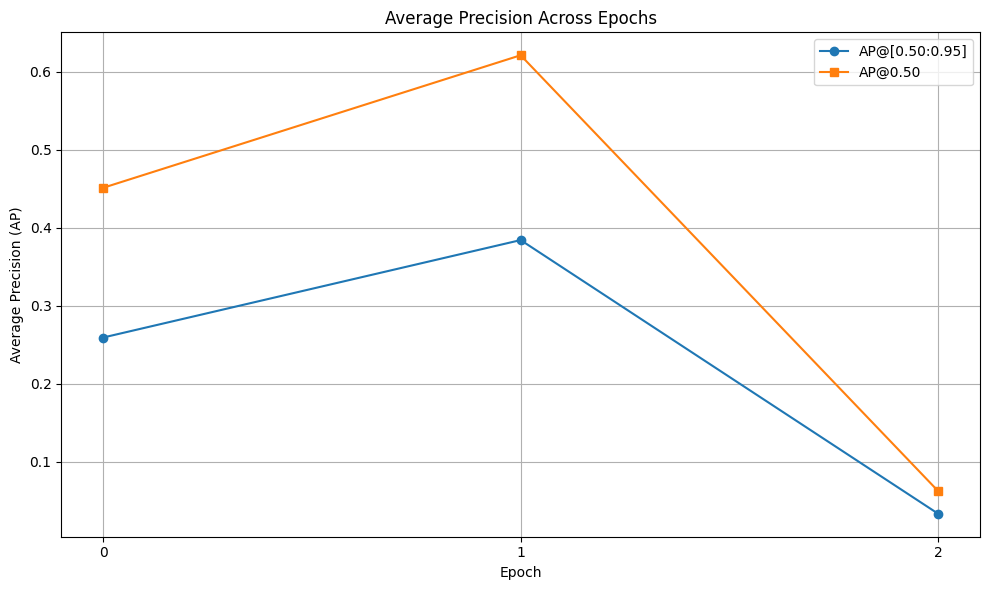

In [ ]:
import matplotlib.pyplot as plt

# Create data for each epoch's evaluation
epochs = [0, 1, 2]
ap_50_95 = [0.259, 0.384, 0.033]  # Average Precision @[ IoU=0.50:0.95 ]
ap_50 = [0.451, 0.621, 0.062]     # Average Precision @[ IoU=0.50 ]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs, ap_50_95, marker='o', label='AP@[0.50:0.95]')
plt.plot(epochs, ap_50, marker='s', label='AP@0.50')

plt.title('Average Precision Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Precision (AP)')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Test one image

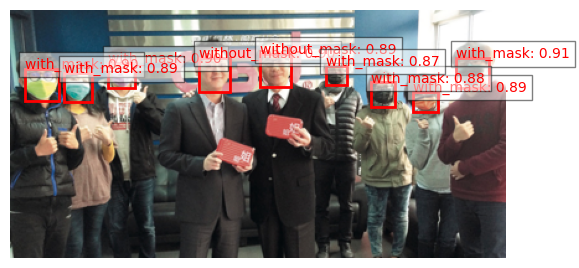

In [ ]:
import matplotlib.patches as patches
from PIL import Image

# Open the image and ensure it's converted to RGB (3 channels)
image = Image.open('/content/W25_COMP263_002_DeepLearning_Group1/dataset/test/maksssksksss164.png').convert("RGB")

# Use the model to perform prediction
detections = model.predict(image)

# Display the image with bounding boxes
fig, ax = plt.subplots(1)
ax.imshow(image)

# Define class names (customize if needed)
class_names = ["with_mask", "without_mask", "mask_weared_incorrect"]

# Iterate through the detection results
for bbox, score, class_id in zip(
    detections.xyxy, detections.confidence, detections.class_id
):
    if score < 0.5:  # Confidence threshold (adjustable)
        continue

    # Convert from xyxy to x, y, width, height
    x1, y1, x2, y2 = bbox
    x, y, w, h = x1, y1, x2 - x1, y2 - y1

    # Draw the bounding box
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    # Display the label with class name and confidence score
    label = f"{class_names[int(class_id)]}: {score:.2f}"
    ax.text(x, y, label, color='r', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

# Hide axis ticks and labels
plt.axis('off')
plt.show()

## Predict test set

In [ ]:
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Set path to test folder and annotations
TEST_DIR = os.path.join(DATASET_DIR, "test")
ANNOTATION_FILE = os.path.join(TEST_DIR, '_annotations.coco.json')

# Load COCO ground truth annotations
coco_gt = COCO(ANNOTATION_FILE)

# Prepare list to store predictions in COCO format
coco_predictions = []

image_ids = coco_gt.getImgIds()
class_names = ["with_mask", "without_mask", "mask_weared_incorrect"]

for img_id in tqdm(image_ids, desc="Evaluating"):
    img_info = coco_gt.loadImgs(img_id)[0]
    image_path = os.path.join(TEST_DIR, img_info['file_name'])

    # Load and convert image
    image = Image.open(image_path).convert("RGB")
    detections = model.predict(image)

    for bbox, score, class_id in zip(
        detections.xyxy, detections.confidence, detections.class_id
    ):
        if score < 0.05:
            continue  # skip low-score predictions

        # Convert bbox from xyxy to COCO format (x, y, width, height)
        x1, y1, x2, y2 = bbox
        x, y, w, h = float(x1), float(y1), float(x2 - x1), float(y2 - y1)

        coco_predictions.append({
            "image_id": img_id,
            "category_id": int(class_id),
            "bbox": [x, y, w, h],
            "score": float(score)
        })

# Save predictions to JSON
pred_path = "test_predictions.json"
with open(pred_path, "w") as f:
    json.dump(coco_predictions, f)

# Load predictions and run COCO evaluation
coco_dt = coco_gt.loadRes(pred_path)
coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Evaluating: 100%|██████████| 172/172 [00:16<00:00, 10.60it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.36s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.490
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.693
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.589
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.413
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.562
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.764
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.285
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.504
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.518
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Building confusion matrix: 100%|██████████| 172/172 [00:14<00:00, 11.96it/s]


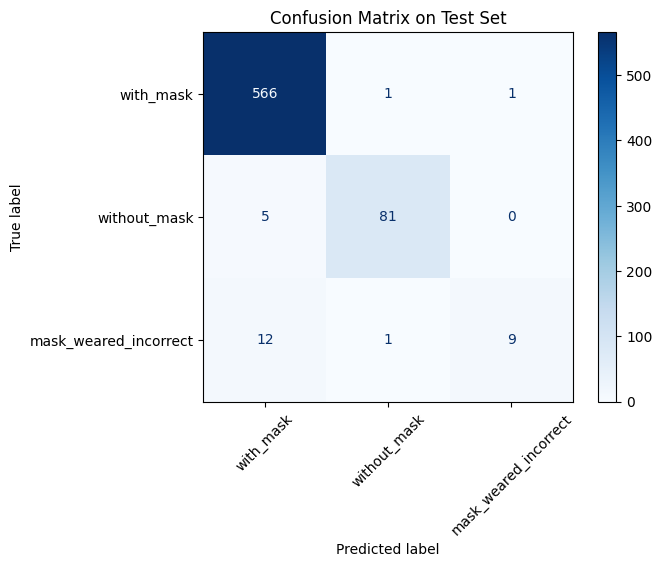

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load COCO annotations
coco_gt = COCO(ANNOTATION_FILE)
image_ids = coco_gt.getImgIds()
class_names = ["with_mask", "without_mask", "mask_weared_incorrect"]

# Containers for true and predicted labels
y_true = []
y_pred = []

# IoU threshold for matching
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

# Loop through test images
for img_id in tqdm(image_ids, desc="Building confusion matrix"):
    img_info = coco_gt.loadImgs(img_id)[0]
    image_path = os.path.join(TEST_DIR, img_info['file_name'])

    image = Image.open(image_path).convert("RGB")
    detections = model.predict(image)

    # Get ground truth boxes and labels
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    anns = coco_gt.loadAnns(ann_ids)
    gt_boxes = [ann['bbox'] for ann in anns]
    gt_labels = [ann['category_id'] for ann in anns]

    matched_gt = set()

    # Match predictions to ground truths by IoU
    for bbox, score, pred_class in zip(
        detections.xyxy, detections.confidence, detections.class_id
    ):
        if score < 0.3:
            continue

        x1, y1, x2, y2 = bbox
        pred_box = [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]
        best_iou = 0
        best_idx = -1

        for i, gt_box in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_idx = i

        if best_iou >= 0.5 and best_idx >= 0:
            y_true.append(gt_labels[best_idx])
            y_pred.append(int(pred_class))
            matched_gt.add(best_idx)

# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.xticks(rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.show()
